In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import timm
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import numpy as np
import seaborn as sns
import os
import urllib.request
from matplotlib import font_manager
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [23]:
!mkdir -p /kaggle/working/merged_data

In [24]:
!cp -r /kaggle/input/bangla-alphabet/splitted/train/* /kaggle/working/merged_data/
!cp -r /kaggle/input/bangla-alphabet/splitted/val/*   /kaggle/working/merged_data/
!cp -r /kaggle/input/bangla-alphabet/splitted/test/*  /kaggle/working/merged_data/

In [25]:
# -------- Device --------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [26]:
DATA_DIR = '/kaggle/working/merged_data/'

dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=transforms.Compose([
        transforms.Resize((224, 224)),# Resize images for ViT and MobileNet input
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize([0.485], [0.229]),  # Normalization
    ])
)

# Split the dataset into training and validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [27]:
batch_size = 16
num_classes = 50  
image_size = 224
epochs = 5
learning_rate = 1.8699e-05

In [28]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [29]:
# -------- Model --------
model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=num_classes)

# Adjust patch embedding to accept 1-channel grayscale input if necessary
if model.patch_embed.proj.in_channels != 1:
    model.patch_embed.proj = nn.Conv2d(1, model.embed_dim, kernel_size=16, stride=16)

model = model.to(device)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [30]:
# -------- Loss and Optimizer --------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [31]:
# -------- Training and Evaluation Functions --------
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    accuracy = correct / total
    return epoch_loss, accuracy

def validate(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    accuracy = correct / total
    return epoch_loss, accuracy

def get_predictions(model, dataloader):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Predicting", leave=False):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [32]:
# -------- Metrics Storage --------
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

In [33]:
# -------- Main Training Loop --------
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")


Epoch 1/5


Train Loss: 2.6695 | Train Acc: 27.26%
Val   Loss: 1.0300 | Val Acc: 67.16%

Epoch 2/5


Train Loss: 0.5703 | Train Acc: 81.93%
Val   Loss: 0.4074 | Val Acc: 87.02%

Epoch 3/5


Train Loss: 0.1920 | Train Acc: 94.00%
Val   Loss: 0.2782 | Val Acc: 91.40%

Epoch 4/5


Train Loss: 0.0492 | Train Acc: 98.92%
Val   Loss: 0.2235 | Val Acc: 93.01%

Epoch 5/5


Train Loss: 0.0138 | Train Acc: 99.94%
Val   Loss: 0.2010 | Val Acc: 94.15%


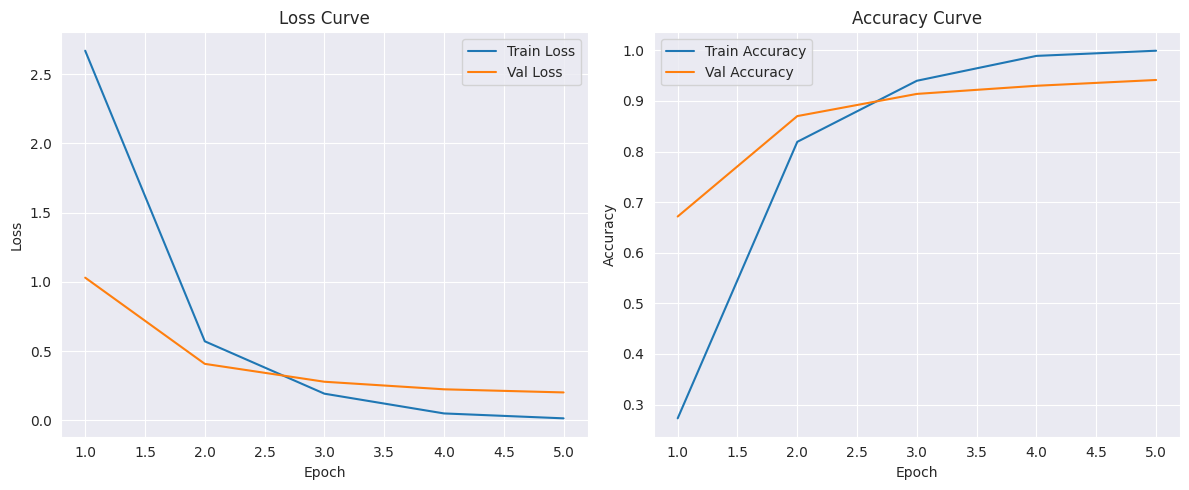

In [34]:
# -------- Plotting Loss and Accuracy Curves --------
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2434 (\N{BENGALI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2435 (\N{BENGALI SIGN VISARGA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2437 (\N{BENGALI LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2439 (\N{BENGALI LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist

Confusion Matrix
Classification Report
              precision    recall  f1-score   support

           ং       0.94      0.96      0.95        71
           ঃ       0.96      1.00      0.98        73
           অ       0.98      0.98      0.98        84
           আ       0.98      0.99      0.98        84
           ই       0.92      0.89      0.90        90
           ঈ       0.95      0.96      0.96        78
           উ       0.90      0.88      0.89        84
           ঊ       0.99      0.91      0.95        80
           ঋ       0.93      0.96      0.95        74
           এ       0.95      0.97      0.96        71
           ঐ       0.90      0.95      0.92        76
           ও       0.91      0.96      0.93        72
           ঔ       0.98      0.92      0.95        87
           ক       0.98      0.97      0.97        98
           খ       0.89      0.85      0.87        80
           গ       0.94      0.98      0.96        86
           ঘ       0.90      0.88      0.8

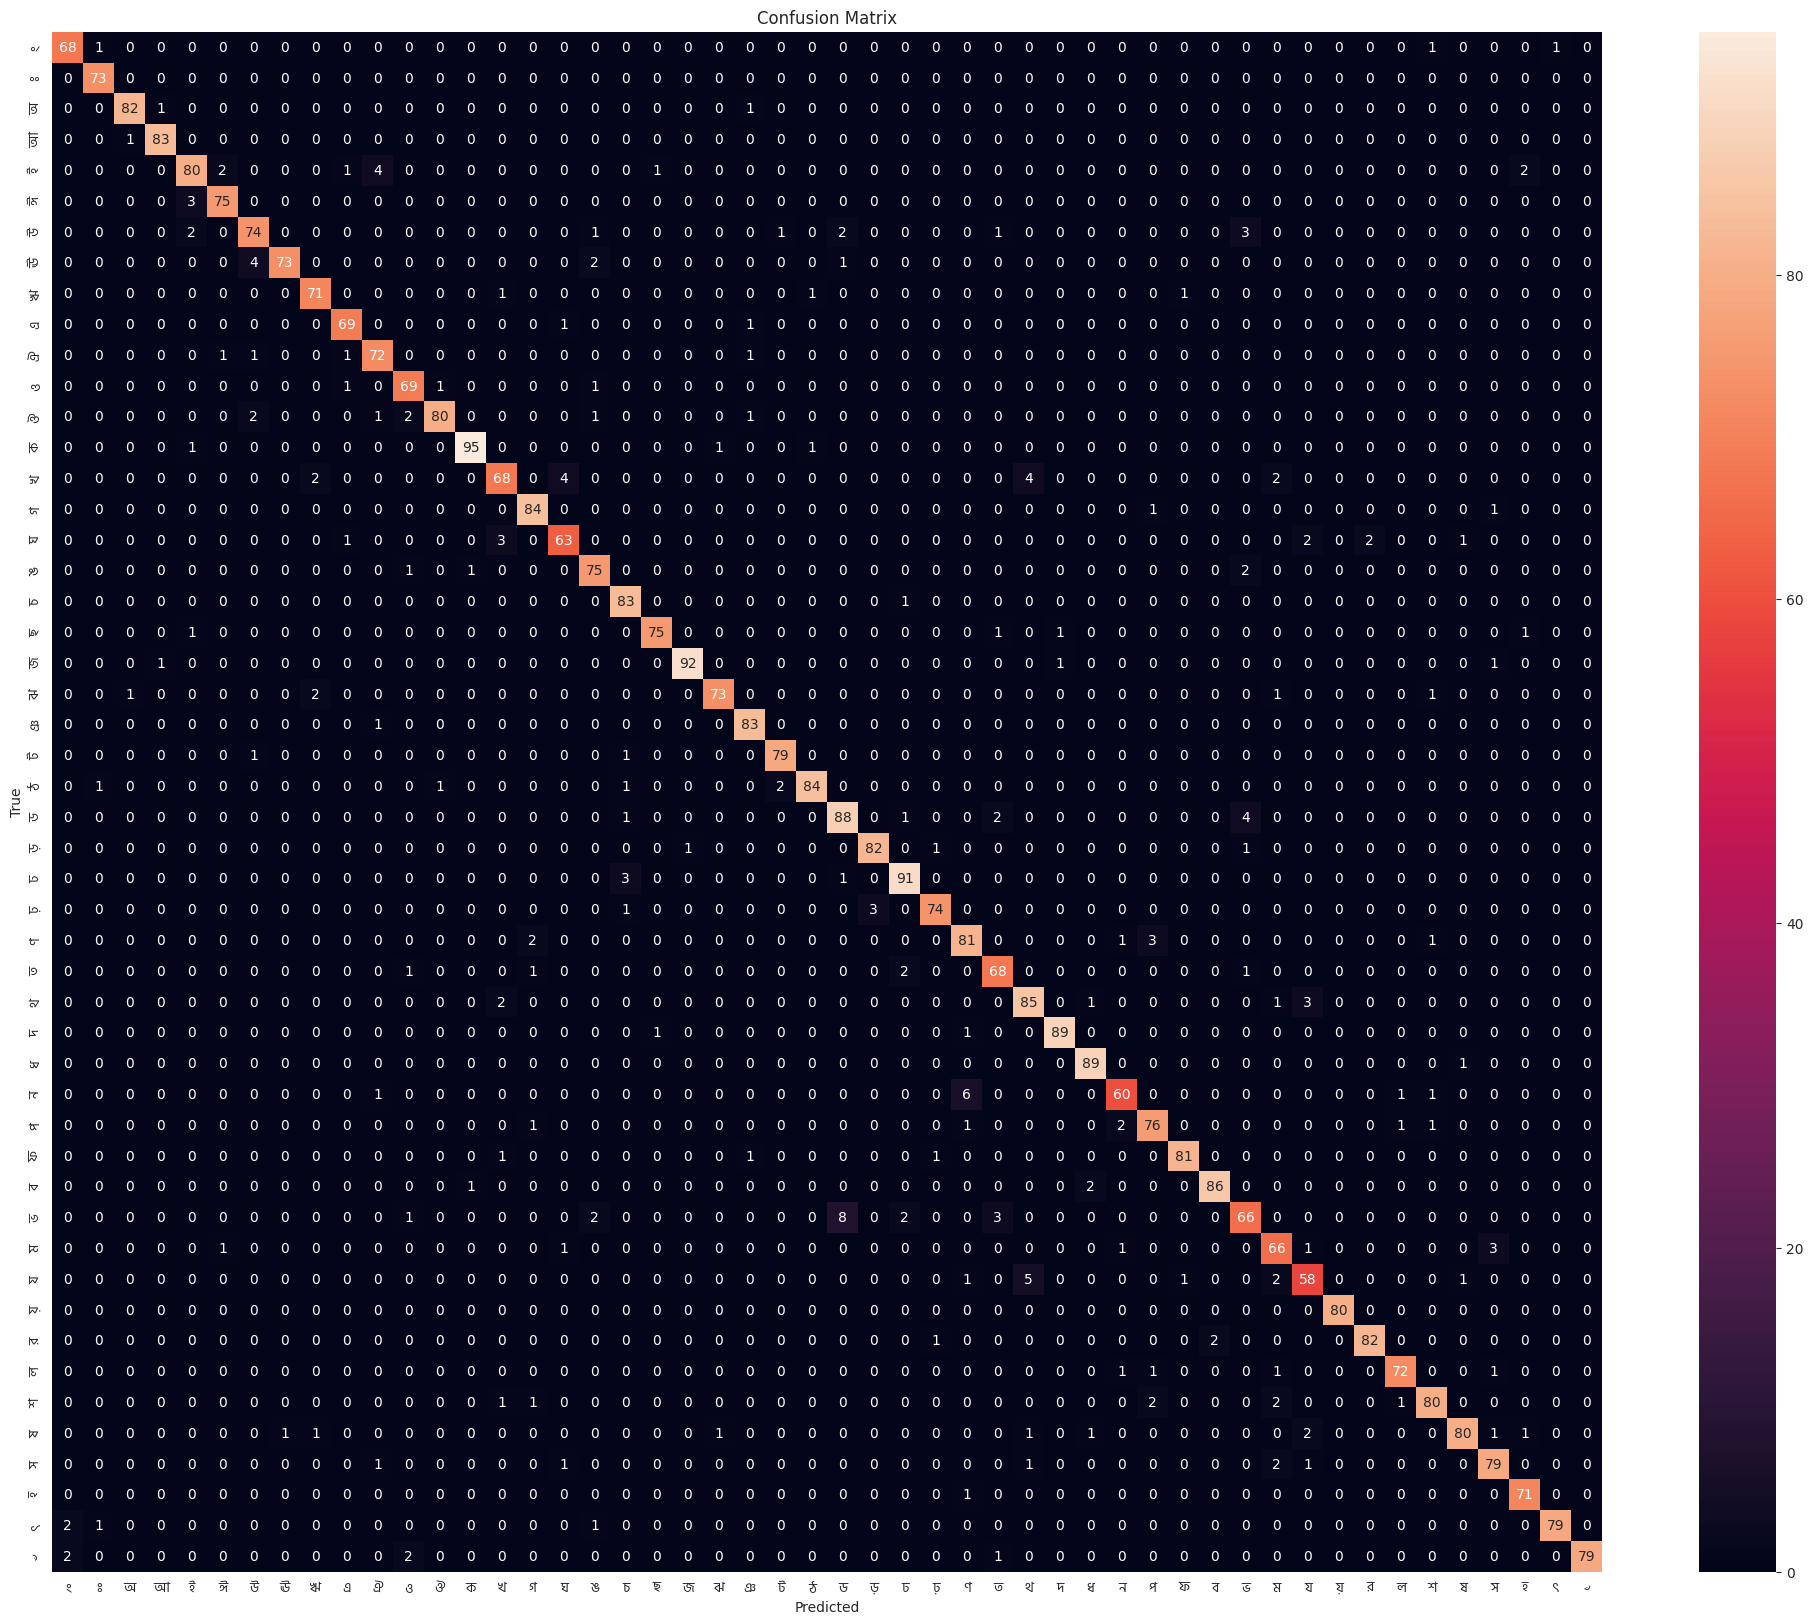

In [37]:
# --- ADDITION 1: FONT DOWNLOAD ---
font_url = "https://github.com/google/fonts/raw/main/ofl/hindsiliguri/HindSiliguri-Regular.ttf"
font_path = "HindSiliguri-Regular.ttf"
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)
bangla_font = font_manager.FontProperties(fname=font_path)

# --- YOUR ORIGINAL LOGIC (Minimal Changes) ---
# # MODIFIED: Replaced model.predict with your get_predictions function
test_labels, y_pred, preds = get_predictions(model, val_loader) 

# # MODIFIED: Replaced Keras class_indices with PyTorch .classes
class_names = dataset.classes 

print('Confusion Matrix')
cm = confusion_matrix(test_labels, y_pred)
print('Classification Report')
print(classification_report(test_labels, y_pred, target_names=class_names))

# --- ADDITION 2: SIZE & SCALING ---
plt.figure(figsize=(25, 20)) # Increased size for 50 classes

# --- MODIFIED HEATMAP CALL ---
ax = sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)

# --- ADDITION 3: BANGLA LABEL FIX ---
for label in ax.get_xticklabels():
    label.set_fontproperties(bangla_font)
for label in ax.get_yticklabels():
    label.set_fontproperties(bangla_font)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
'''
import optuna
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def validate(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

def objective(trial):
    # Hyperparameters to tune
    lr = trial.suggest_loguniform('lr', 1e-5, 1e-3)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=num_classes)
    # Adjust patch embedding for grayscale input
    if model.patch_embed.proj.in_channels != 1:
        model.patch_embed.proj = nn.Conv2d(1, model.embed_dim, kernel_size=16, stride=16)
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    for epoch in range(epochs):
        train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = validate(model, val_loader, criterion)
        scheduler.step()

    return val_acc  # maximize validation accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print("Best hyperparameters:", study.best_params)
print(f"Best validation accuracy: {study.best_value:.4f}")
'''